# Sales Forecasting Using Time Series Analysis

**Internship Project – Naviotech Solution Pvt. Ltd.**

This notebook performs end-to-end sales forecasting using the Superstore dataset supplied in the internship material.

### Workflow
1. Business problem and objectives
2. Import libraries
3. Load and inspect data
4. Data cleaning
5. Exploratory Data Analysis
6. Monthly time-series creation
7. Decomposition and stationarity testing
8. ACF/PACF analysis
9. Train/test split
10. Baseline, Exponential Smoothing, Holt, Holt-Winters, ARIMA and SARIMA
11. Model evaluation
12. Final model selection
13. Future sales forecast
14. Conclusion

## 1. Business Problem

Businesses need reliable estimates of future sales for inventory planning, budgeting, staffing, procurement, and marketing decisions. The goal of this project is to use historical sales data to identify trend and seasonality and forecast future monthly sales.

## 2. Objectives

- Clean and prepare historical sales data.
- Explore sales trends and seasonal behavior.
- Convert transaction-level data into a monthly time series.
- Test stationarity using the Augmented Dickey-Fuller test.
- Study ACF and PACF.
- Implement multiple forecasting models.
- Compare models using MAE, RMSE and MAPE.
- Forecast future sales using the selected model.

In [1]:
# Install packages only if needed (uncomment when required)
# %pip install pandas numpy matplotlib seaborn scikit-learn statsmodels openpyxl

import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

## 3. Load Dataset

The project uses the `Superstore.xlsx` file supplied in the internship Week 1 material. The notebook expects the file at `../data/Superstore.xlsx` relative to this notebook.

In [2]:
DATA_PATH = os.path.join('..', 'data', 'Superstore.xlsx')

if not os.path.exists(DATA_PATH):
    # Fallback for running the notebook from the project root
    DATA_PATH = os.path.join('data', 'Superstore.xlsx')

df = pd.read_excel(DATA_PATH, sheet_name='Orders')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
print('Columns:')
print(df.columns.tolist())

print('\nData types:')
print(df.dtypes)

print('\nMissing values:')
print(df.isnull().sum())

print('\nDuplicate rows:', df.duplicated().sum())

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

Data types:
Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

Missing values:
Row ID         

## 4. Data Cleaning and Preparation

In [4]:
df = df.copy()

df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

df = df.dropna(subset=['Order Date', 'Sales'])
df = df.drop_duplicates()
df = df.sort_values('Order Date')

print('Cleaned shape:', df.shape)
print('Date range:', df['Order Date'].min().date(), 'to', df['Order Date'].max().date())

Cleaned shape: (9994, 21)
Date range: 2014-01-03 to 2017-12-30


## 5. Exploratory Data Analysis

In [5]:
print(df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().T)

           count        mean         std       min       25%      50%  \
Sales     9994.0  229.858001  623.245101     0.444  17.28000  54.4900   
Quantity  9994.0    3.789574    2.225110     1.000   2.00000   3.0000   
Discount  9994.0    0.156203    0.206452     0.000   0.00000   0.2000   
Profit    9994.0   28.656896  234.260108 -6599.978   1.72875   8.6665   

              75%        max  
Sales     209.940  22638.480  
Quantity    5.000     14.000  
Discount    0.200      0.800  
Profit     29.364   8399.976  


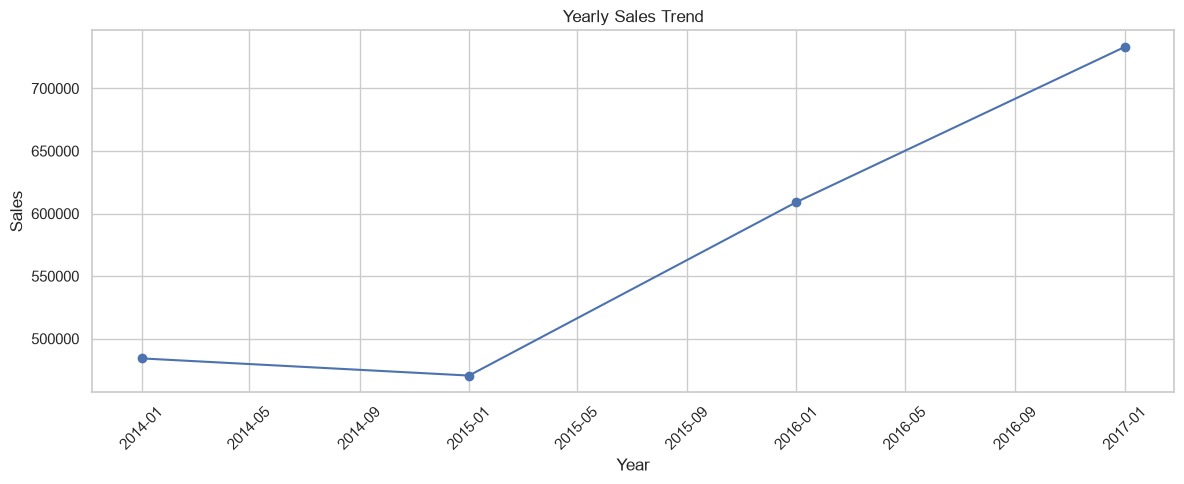

In [6]:
# Overall sales by year
yearly_sales = df.set_index('Order Date')['Sales'].resample('YS').sum()

plt.figure(figsize=(12, 5))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o')
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

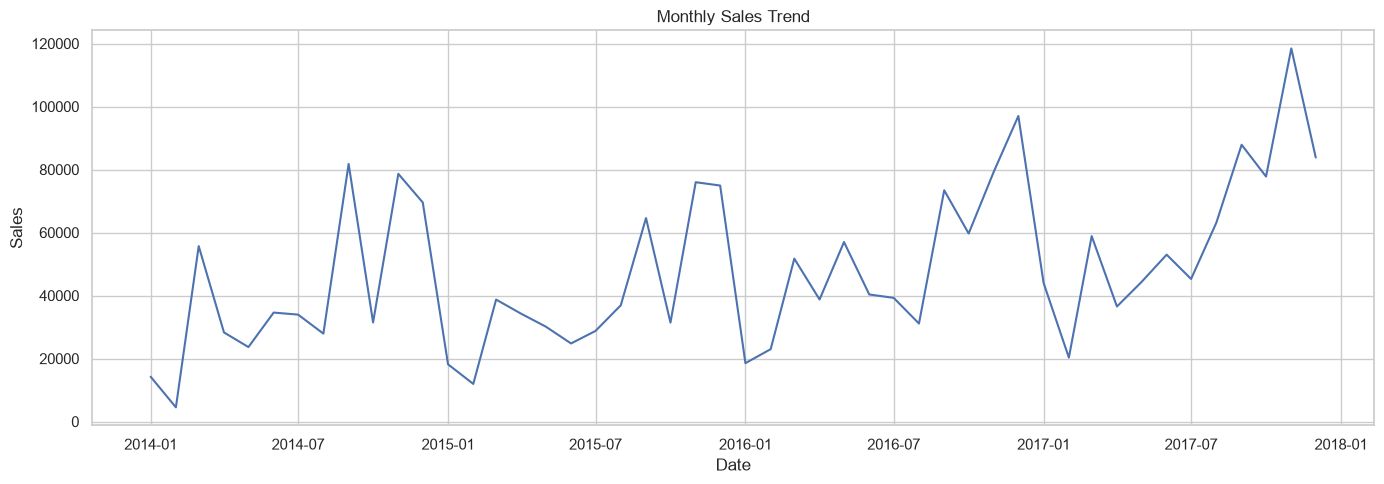

In [7]:
# Monthly transaction-level sales aggregated across all years
monthly_sales_calendar = df.set_index('Order Date')['Sales'].resample('MS').sum()

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales_calendar.index, monthly_sales_calendar.values)
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

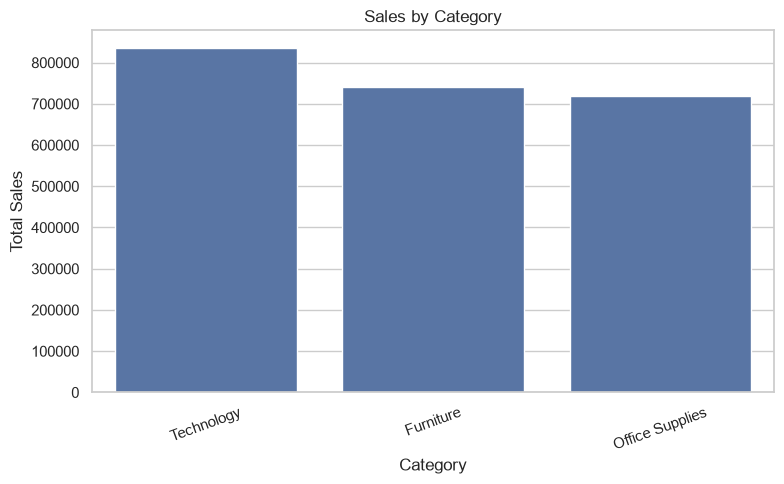

In [8]:
# Sales by category
if 'Category' in df.columns:
    category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=category_sales.index, y=category_sales.values)
    plt.title('Sales by Category')
    plt.xlabel('Category')
    plt.ylabel('Total Sales')
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()

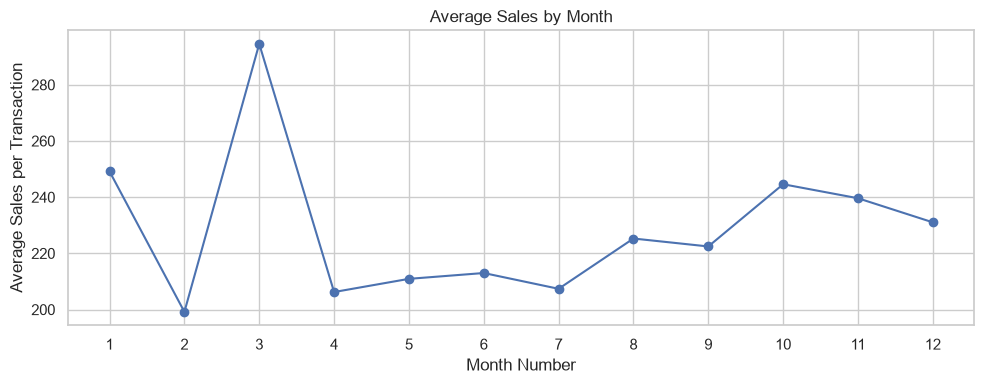

In [9]:
# Monthly seasonality profile: average sales by calendar month
monthly_profile = df.assign(Month=df['Order Date'].dt.month).groupby('Month')['Sales'].mean()

plt.figure(figsize=(10, 4))
plt.plot(monthly_profile.index, monthly_profile.values, marker='o')
plt.title('Average Sales by Month')
plt.xlabel('Month Number')
plt.ylabel('Average Sales per Transaction')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

## 6. Create the Forecasting Time Series

For forecasting, transaction-level observations are aggregated to **monthly total sales**. This gives a regular time series suitable for seasonal forecasting.

In [10]:
sales_ts = (
    df.set_index('Order Date')['Sales']
      .resample('MS')
      .sum()
      .asfreq('MS')
)

print(sales_ts.head())
print('Number of monthly observations:', len(sales_ts))

Order Date
2014-01-01    14236.895
2014-02-01     4519.892
2014-03-01    55691.009
2014-04-01    28295.345
2014-05-01    23648.287
Freq: MS, Name: Sales, dtype: float64
Number of monthly observations: 48


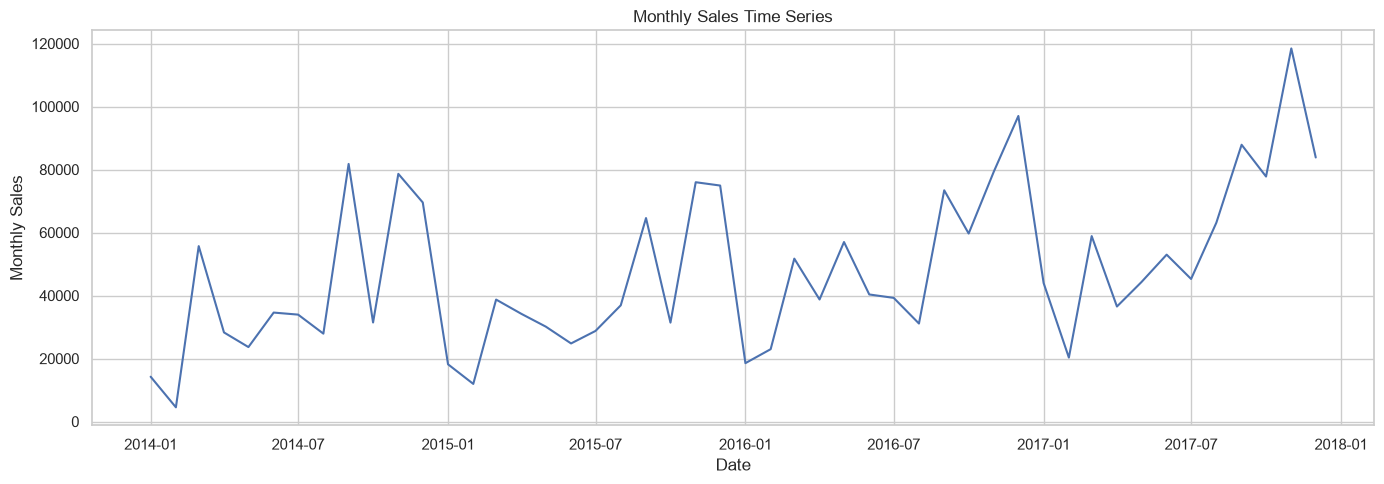

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(sales_ts.index, sales_ts.values)
plt.title('Monthly Sales Time Series')
plt.xlabel('Date')
plt.ylabel('Monthly Sales')
plt.tight_layout()
plt.show()

## 7. Time-Series Decomposition

We decompose the series into observed, trend, seasonal and residual components. Because the data is monthly, a seasonal period of 12 represents yearly seasonality.

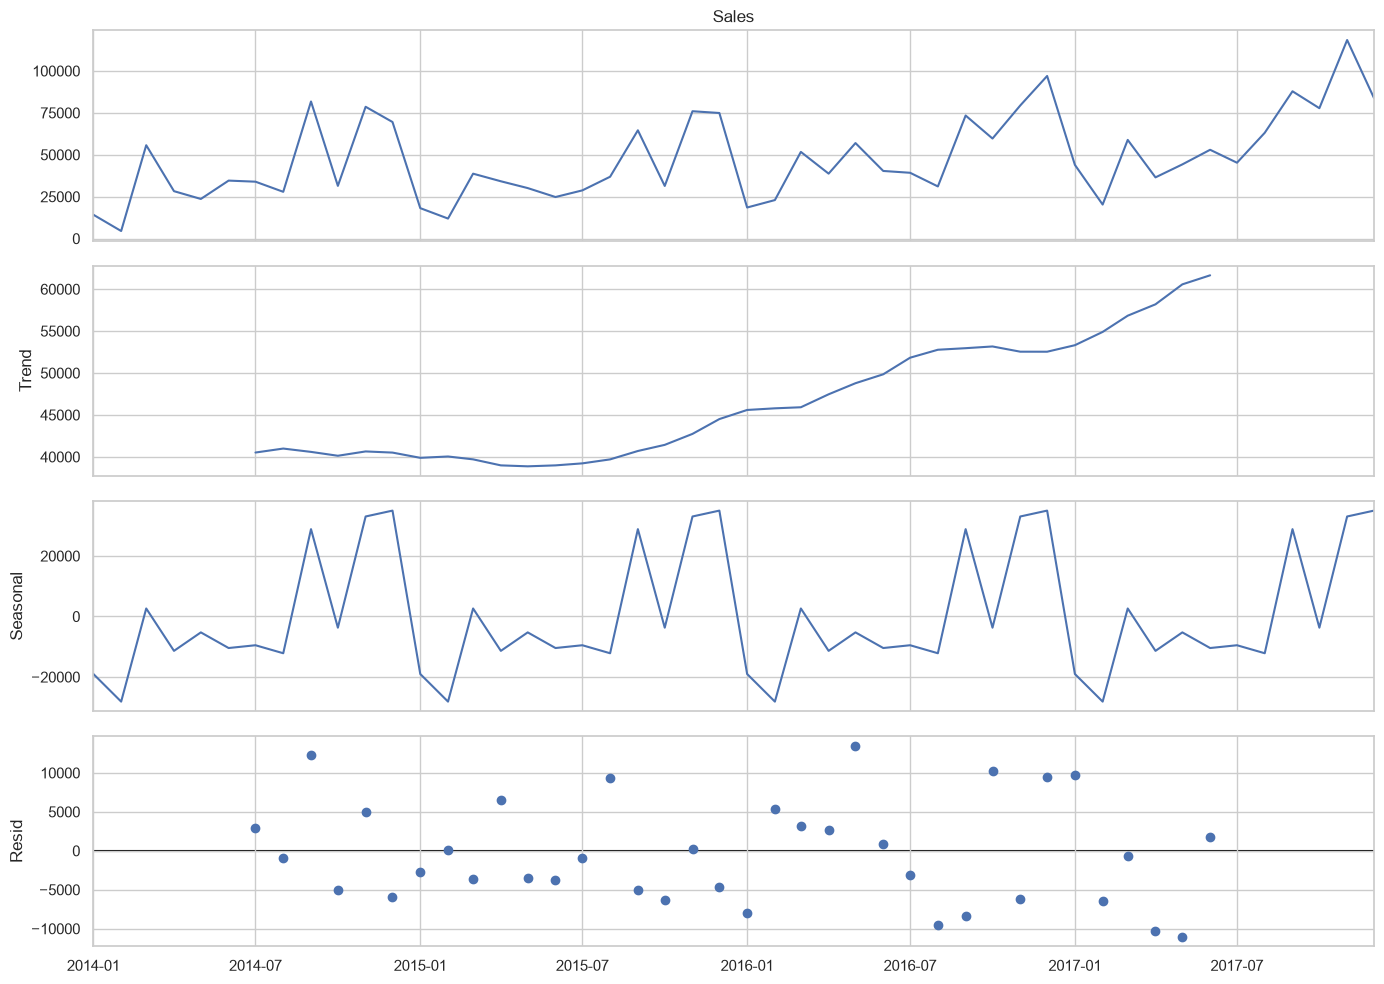

In [12]:
decomposition = seasonal_decompose(sales_ts, model='additive', period=12)
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

## 8. Stationarity – Augmented Dickey-Fuller Test

A stationary series has stable statistical properties over time. ARIMA-family models commonly use differencing to make a non-stationary series stationary.

In [13]:
def adf_test(series, name='Series'):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Test: {name}')
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'  {key}: {value}')
    if result[1] < 0.05:
        print('Conclusion: Stationary (reject H0 at 5%).')
    else:
        print('Conclusion: Non-stationary (fail to reject H0 at 5%).')

adf_test(sales_ts, 'Original Monthly Sales')

ADF Test: Original Monthly Sales
ADF Statistic: -4.493767844002665
p-value: 0.00020180198458237758
Critical Values:
  1%: -3.5778480370438146
  5%: -2.925338105429433
  10%: -2.6007735310095064
Conclusion: Stationary (reject H0 at 5%).


ADF Test: First Difference
ADF Statistic: -9.057696814193994
p-value: 4.653163912897081e-15
Critical Values:
  1%: -3.626651907578875
  5%: -2.9459512825788754
  10%: -2.6116707716049383
Conclusion: Stationary (reject H0 at 5%).


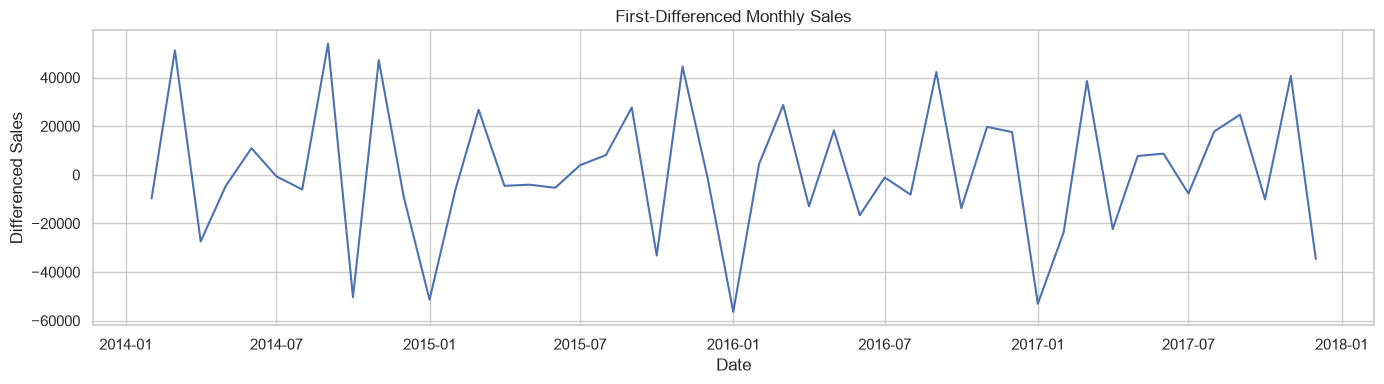

In [14]:
# First difference for inspection
diff1 = sales_ts.diff().dropna()
adf_test(diff1, 'First Difference')

plt.figure(figsize=(14, 4))
plt.plot(diff1.index, diff1.values)
plt.title('First-Differenced Monthly Sales')
plt.xlabel('Date')
plt.ylabel('Differenced Sales')
plt.tight_layout()
plt.show()

## 9. ACF and PACF

ACF helps study correlation between observations and their lags. PACF helps identify the direct relationship at each lag after accounting for shorter lags. These plots support ARIMA/SARIMA order selection.

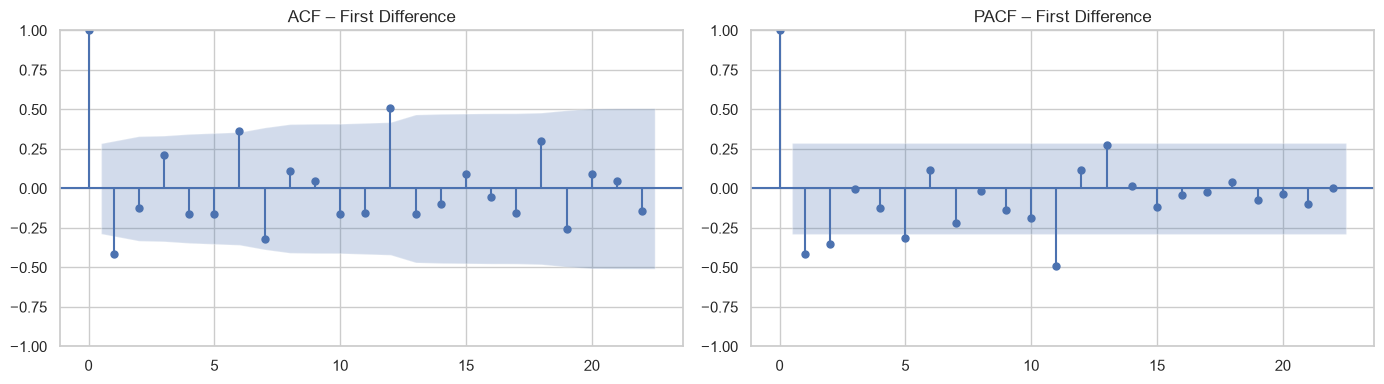

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff1, ax=axes[0], lags=min(24, len(diff1)//2 - 1))
plot_pacf(diff1, ax=axes[1], lags=min(24, len(diff1)//2 - 1), method='ywm')
axes[0].set_title('ACF – First Difference')
axes[1].set_title('PACF – First Difference')
plt.tight_layout()
plt.show()

## 10. Train/Test Split

Time series data must be split chronologically. The final 12 months are reserved as a test set, while earlier months are used for training.

In [16]:
test_size = 12
if len(sales_ts) <= test_size + 12:
    raise ValueError('The time series is too short for a 12-month test set and seasonal modeling.')

train = sales_ts.iloc[:-test_size]
test = sales_ts.iloc[-test_size:]

print('Training period:', train.index.min().date(), 'to', train.index.max().date())
print('Testing period :', test.index.min().date(), 'to', test.index.max().date())

Training period: 2014-01-01 to 2016-12-01
Testing period : 2017-01-01 to 2017-12-01


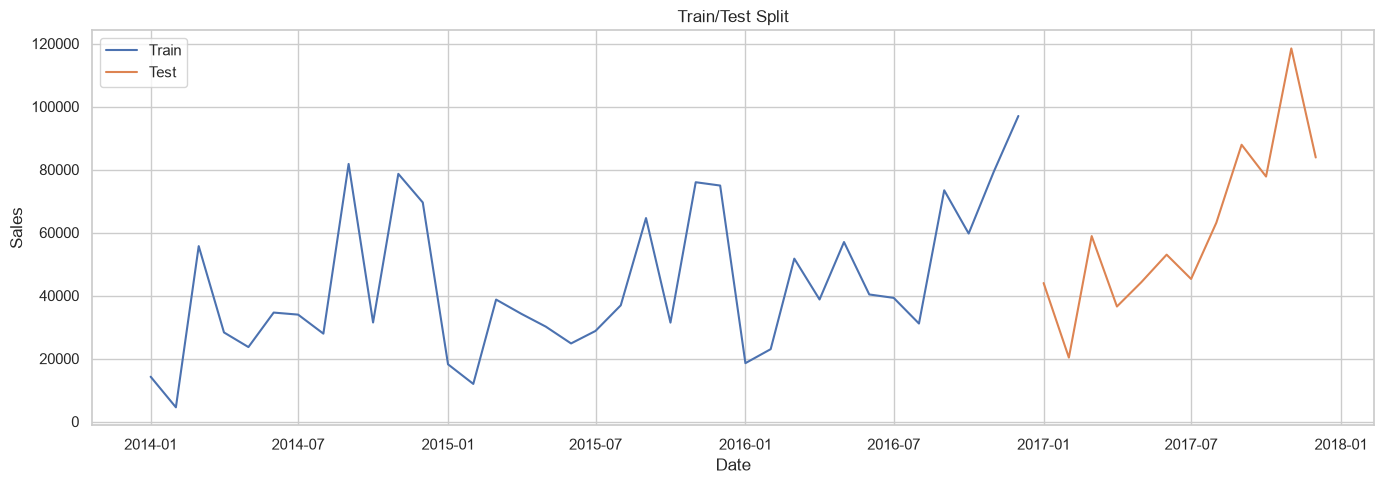

In [17]:
plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Test')
plt.title('Train/Test Split')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

## 11. Forecasting Metrics

In [18]:
def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_model(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape(actual, predicted)}

## 12. Baseline – Naive Forecast

In [19]:
naive_forecast = pd.Series(train.iloc[-1], index=test.index)
results = []
results.append(evaluate_model('Naive', test, naive_forecast))

print(results[-1])

{'Model': 'Naive', 'MAE': 39472.56873333334, 'RMSE': np.float64(44191.88603704968), 'MAPE (%)': np.float64(97.32309573436231)}


## 13. Simple Exponential Smoothing

In [20]:
ses_fit = SimpleExpSmoothing(train).fit(optimized=True)
ses_forecast = ses_fit.forecast(test_size)
results.append(evaluate_model('Simple Exponential Smoothing', test, ses_forecast))
print(results[-1])

{'Model': 'Simple Exponential Smoothing', 'MAE': 24305.402731775477, 'RMSE': np.float64(28085.27142302369), 'MAPE (%)': np.float64(57.68997219682285)}


## 14. Holt Linear Trend

In [21]:
holt_fit = Holt(train).fit(optimized=True)
holt_forecast = holt_fit.forecast(test_size)
results.append(evaluate_model("Holt's Linear Trend", test, holt_forecast))
print(results[-1])

{'Model': "Holt's Linear Trend", 'MAE': 56450.43719439547, 'RMSE': np.float64(58442.44559602856), 'MAPE (%)': np.float64(122.70938350996829)}


## 15. Holt-Winters Exponential Smoothing

In [22]:
hw_fit = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)
hw_forecast = hw_fit.forecast(test_size)
results.append(evaluate_model('Holt-Winters', test, hw_forecast))
print(results[-1])

{'Model': 'Holt-Winters', 'MAE': 10679.862213201997, 'RMSE': np.float64(13991.531302994334), 'MAPE (%)': np.float64(17.599496175085026)}


## 16. ARIMA

In [23]:
arima_order = (1, 1, 1)
arima_fit = ARIMA(train, order=arima_order).fit()
arima_forecast = arima_fit.forecast(steps=test_size)
results.append(evaluate_model('ARIMA(1,1,1)', test, arima_forecast))
print(results[-1])

{'Model': 'ARIMA(1,1,1)', 'MAE': 23450.62722593854, 'RMSE': np.float64(27208.447422550846), 'MAPE (%)': np.float64(54.10577087234649)}


## 17. SARIMA

For monthly retail sales, yearly seasonality can be represented with seasonal period 12.

In [24]:
sarima_order = (1, 1, 1)
sarima_seasonal_order = (1, 1, 1, 12)

sarima_fit = SARIMAX(
    train,
    order=sarima_order,
    seasonal_order=sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_forecast = sarima_fit.forecast(steps=test_size)
results.append(evaluate_model('SARIMA(1,1,1)(1,1,1,12)', test, sarima_forecast))
print(results[-1])

{'Model': 'SARIMA(1,1,1)(1,1,1,12)', 'MAE': 13580.179343521711, 'RMSE': np.float64(16260.698283016021), 'MAPE (%)': np.float64(26.84439877966373)}


## 18. Model Comparison

In [25]:
results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df

,Model,MAE,RMSE,MAPE (%)
0,Holt-Winters,10679.862213,13991.531303,17.599496
1,"SARIMA(1,1,1)(1,1,1,12)",13580.179344,16260.698283,26.844399
2,"ARIMA(1,1,1)",23450.627226,27208.447423,54.105771
3,Simple Exponential Smoothing,24305.402732,28085.271423,57.689972
4,Naive,39472.568733,44191.886037,97.323096
5,Holt's Linear Trend,56450.437194,58442.445596,122.709384


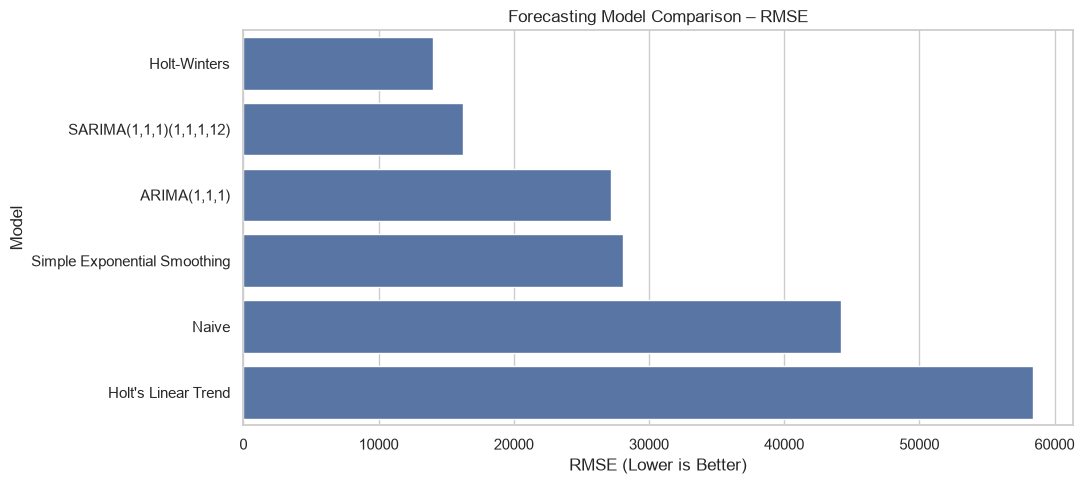

In [26]:
plt.figure(figsize=(11, 5))
sns.barplot(data=results_df, x='RMSE', y='Model')
plt.title('Forecasting Model Comparison – RMSE')
plt.xlabel('RMSE (Lower is Better)')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

## 19. Actual vs Predicted Sales

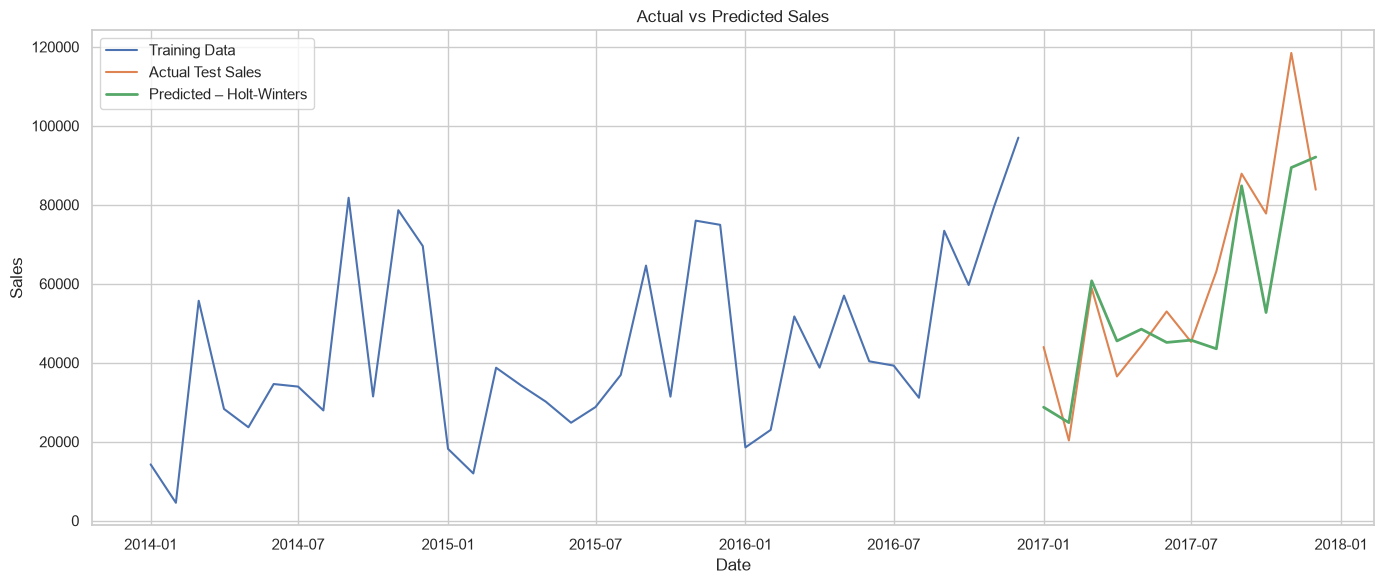

Selected best model based on RMSE: Holt-Winters


In [27]:
forecast_dict = {
    'Naive': naive_forecast,
    'Simple Exponential Smoothing': ses_forecast,
    "Holt's Linear Trend": holt_forecast,
    'Holt-Winters': hw_forecast,
    'ARIMA(1,1,1)': arima_forecast,
    'SARIMA(1,1,1)(1,1,1,12)': sarima_forecast
}

best_model_name = results_df.iloc[0]['Model']
best_test_forecast = forecast_dict[best_model_name]

plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label='Training Data')
plt.plot(test.index, test, label='Actual Test Sales')
plt.plot(test.index, best_test_forecast, label=f'Predicted – {best_model_name}', linewidth=2)
plt.title('Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

print('Selected best model based on RMSE:', best_model_name)

## 20. Refit Best Model on Full Data and Forecast Future Sales

After model comparison, the selected model is retrained on all available historical observations before producing the final future forecast.

In [28]:
future_horizon = 12

if best_model_name == 'Naive':
    final_forecast = pd.Series(sales_ts.iloc[-1], index=pd.date_range(sales_ts.index[-1] + pd.offsets.MonthBegin(1), periods=future_horizon, freq='MS'))
elif best_model_name == 'Simple Exponential Smoothing':
    final_fit = SimpleExpSmoothing(sales_ts).fit(optimized=True)
    final_forecast = final_fit.forecast(future_horizon)
elif best_model_name == "Holt's Linear Trend":
    final_fit = Holt(sales_ts).fit(optimized=True)
    final_forecast = final_fit.forecast(future_horizon)
elif best_model_name == 'Holt-Winters':
    final_fit = ExponentialSmoothing(sales_ts, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
    final_forecast = final_fit.forecast(future_horizon)
elif best_model_name == 'ARIMA(1,1,1)':
    final_fit = ARIMA(sales_ts, order=(1,1,1)).fit()
    final_forecast = final_fit.forecast(future_horizon)
else:
    final_fit = SARIMAX(
        sales_ts, order=(1,1,1), seasonal_order=(1,1,1,12),
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)
    final_forecast = final_fit.forecast(future_horizon)

forecast_table = pd.DataFrame({'Forecast Sales': final_forecast})
forecast_table

,Forecast Sales
2018-01-01,49696.758506
2018-02-01,41841.212443
2018-03-01,74870.726761
2018-04-01,61539.481835
2018-05-01,68507.585806
2018-06-01,65391.021875
2018-07-01,67083.218550
2018-08-01,66664.919542
2018-09-01,108146.222504
2018-10-01,77811.814226


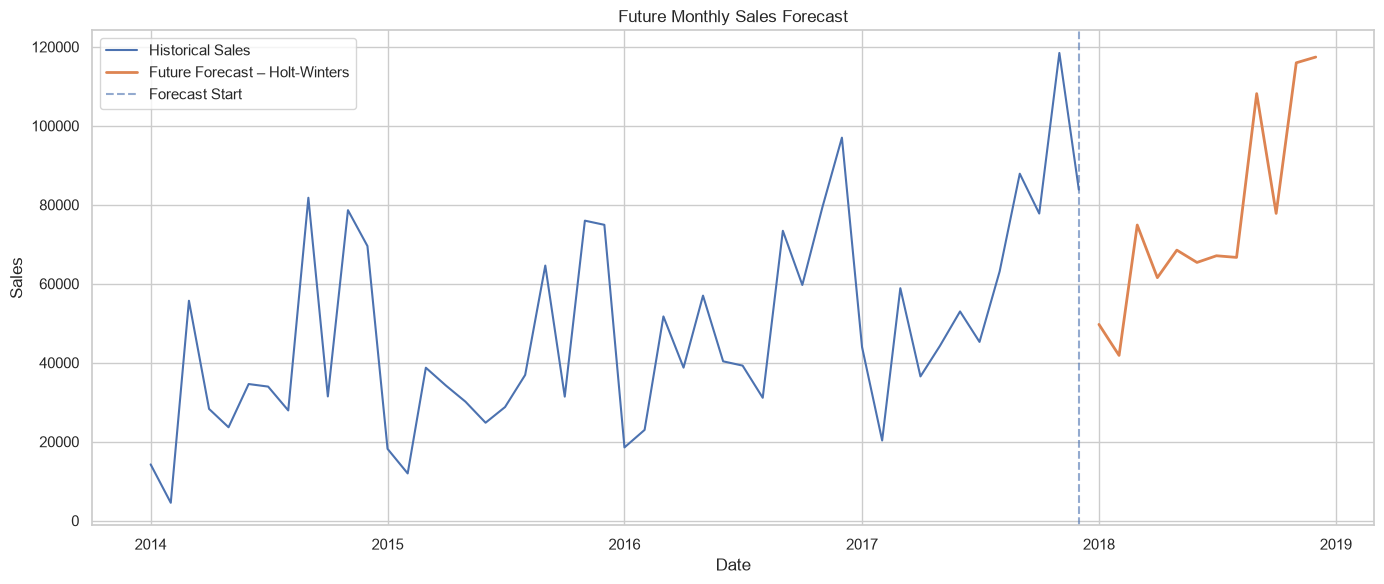

In [29]:
plt.figure(figsize=(14, 6))
plt.plot(sales_ts.index, sales_ts.values, label='Historical Sales')
plt.plot(final_forecast.index, final_forecast.values, label=f'Future Forecast – {best_model_name}', linewidth=2)
plt.axvline(sales_ts.index[-1], linestyle='--', alpha=0.6, label='Forecast Start')
plt.title('Future Monthly Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

## 21. Save Results

The next cell creates an `outputs` folder and saves the model comparison and forecast table. Image files can be added later if required for the report/PPT.

In [30]:
OUTPUT_DIR = os.path.join('..', 'outputs')
if not os.path.exists(OUTPUT_DIR):
    OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

results_df.to_csv(os.path.join(OUTPUT_DIR, 'model_comparison.csv'), index=False)
forecast_table.to_csv(os.path.join(OUTPUT_DIR, 'future_sales_forecast.csv'))

print('Saved: model_comparison.csv')
print('Saved: future_sales_forecast.csv')

Saved: model_comparison.csv
Saved: future_sales_forecast.csv


## 22. Key Findings and Conclusion

After running the notebook, replace the placeholders below with your actual results.

- The dataset contains historical retail transactions that were aggregated into monthly sales.
- EDA was used to understand sales trend and seasonal behavior.
- The ADF test was used to assess stationarity.
- ACF/PACF supported ARIMA-family model analysis.
- Multiple forecasting methods were evaluated using MAE, RMSE and MAPE.
- The model with the lowest RMSE was selected for the final forecast.
- The final model was refit on the complete historical series and used to forecast the next 12 months.

**Important:** The final numerical results should be taken from the cells after execution, not from sample values.